# **TikTok Project**


### **Exploratory Data Analysis**  

This project involves examining and preparing a dataset for analysis, followed by designing a professional data visualization that effectively conveys insights to support data-driven business decisions.  

The objective is to conduct an exploratory data analysis (EDA) to understand key patterns and relationships within the dataset. A primary focus is identifying factors that differentiate claim videos from opinion videos.  

The analysis consists of four main stages:  

1. **Data Exploration and Cleaning** – Identifying missing values, handling inconsistencies, and understanding variable distributions.  
2. **Visualization Development** – Creating informative visual representations of the findings.  
3. **Conclusions** – Interpreting results and summarizing key takeaways.  

Through this process, the goal is to uncover meaningful insights that enhance understanding of content engagement trends.

# **PACE stages**

Throughout this project, references to the PACE problem-solving framework will appear. Each section of the notebook is aligned with a specific PACE stage: Plan, Analyze, Construct, and Execute. This structured approach ensures a systematic exploration of the dataset, from initial planning to final execution.


## **PACE: Plan**  

### Identifying Outliers  

To analyze the central tendency and understand the range of data values, it is necessary to calculate the mean and median of the dataset. Additionally, using histograms can provide a clear visualization of data distribution and potential outliers.  

### Handling Outliers  

Deciding whether to keep, remove, or replace outliers depends on the dataset and the analysis objectives:  

- **Remove**: If outliers result from data entry errors or inconsistencies and could negatively impact modeling, removing them may be appropriate.  
- **Replace**: In cases where the dataset is small or outliers could distort modeling outcomes, replacing them with derived values (such as the median) helps maintain structure.  
- **Retain**: For exploratory data analysis or models that are robust to outliers, keeping them ensures the dataset remains complete for thorough investigation.

For exploratory data analysis (EDA), it is essential to import relevant packages that facilitate data manipulation, statistical analysis, and visualization.

In [2]:
# Import packages for data manipulation
import pandas as pd
import numpy as np


# Import packages for data visualization
import seaborn as sns
from matplotlib import pyplot as plt

Then, load the dataset into a dataframe.

In [5]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

## **PACE: Analyze**


### **1. Data exploration and cleaning**

The first step is to assess the data by identifying any missing values and potential outliers. Handling missing data depends on the dataset and analysis goals, while outliers require evaluation to determine their impact.

In [6]:
# Display and examine the first few rows of the dataframe
data.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [8]:
# Get the size of the data
data.size


232584

In [9]:
# Get the shape of the data
data.shape


(19382, 12)

Get basic information about the data, using `.info()`.

In [10]:
# Get basic information about the data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Generate a table of descriptive statistics with `.describe()`.

In [11]:
# Generate a table of descriptive statistics
data.describe()


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


### **2. Visualization Development - Select visualization type(s)**

Select appropriate data visualizations to explore and interpret the dataset. 

Box plots and histograms are particularly useful for analyzing data distribution, helping to identify trends, outliers, and skewness. Understanding distribution patterns guides further data analysis and modeling decisions.


## **PACE: Construct**


### **Build visualizations**

Now it’s time to plot visualization.

#### **video_duration_sec**

Generate a box plot to visualize the distribution and spread of values in the `video_duration_sec` column. This will help identify potential outliers and understand the overall range of video durations.

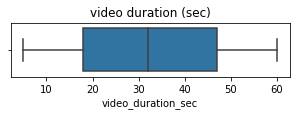

In [14]:
# Create a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize = (5,1))
plt.title('video duration (sec)')
sns.boxplot(x = data['video_duration_sec'])


Create a histogram of the video_duration_sec column to gain deeper insights into the distribution of video durations. This visualization will help identify patterns such as skewness, peaks, or gaps in the data.

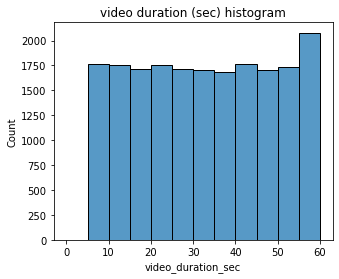

In [26]:
# Create a histogram
# Create a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize = (5,4))
plt.title('video duration (sec) histogram')
sns.histplot(data['video_duration_sec'], bins= range(0, 61, 5))


The video durations range from 5 to 60 seconds, with a uniform distribution across this range.

#### **video_view_count**

Box plot to examine the spread of values in the `video_view_count` column.

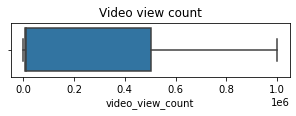

In [23]:
# Create a boxplot to visualize distribution of `video_view_count`
plt.figure(figsize = (5,1))
plt.title('Video view count')
sns.boxplot(x = data['video_view_count'])


Histogram of the values in the `video_view_count` column to further explore the distribution of this variable.

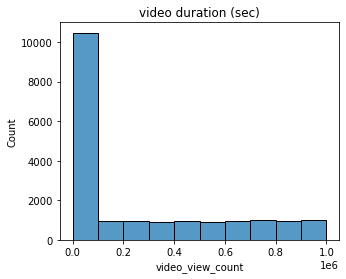

In [32]:
# Create a histogram


plt.figure(figsize = (5,4))
plt.title('video duration (sec)')
sns.histplot(x = data['video_view_count'], bins = range(0,10**6+1,10**5))



The distribution of views is highly skewed, with more than half of the videos receiving fewer than 100,000 views.

#### **video_like_count**

Box plot to examine the spread of values in the `video_like_count` column.

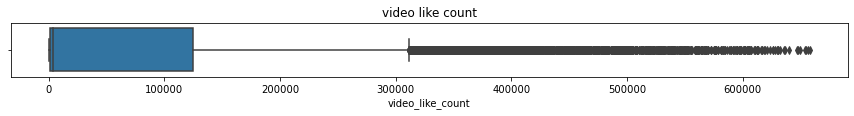

In [44]:
# Create a boxplot to visualize distribution of `video_like_count`
plt.figure(figsize = (15,1))
plt.title('video like count')
sns.boxplot(x = data['video_like_count'])

Histogram of the values in the `video_like_count` column to further explore the distribution of this variable.

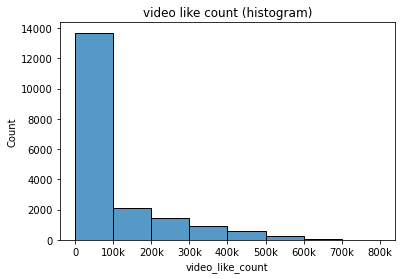

In [60]:
# Create a histogram
ax = sns.histplot(data['video_like_count'], bins = range(0, (8*10**5+1),10**5))
labels = [0] + [str(i) + 'k' for i in range(100, 801, 100)]
ax.set_xticks(range(0,8*10**5+1,10**5))
ax.set_xticklabels(labels)
plt.title('video like count (histogram)');
              



The majority of videos have fewer than 100,000 likes, with only a smaller number surpassing this threshold. The distribution is right-skewed, showing a gradual taper, with a significant number of videos achieving exceptionally high like counts.

#### **video_comment_count**

Box plot to examine the spread of values in the `video_comment_count` column.

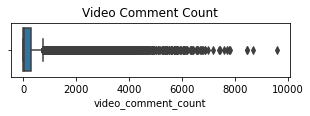

In [67]:
# Create a boxplot to visualize distribution of `video_comment_count`
plt.figure(figsize = (5,1))
plt.title('Video Comment Count')
sns.boxplot(data['video_comment_count'])



Histogram of the values in the `video_comment_count` column to further explore the distribution of this variable.

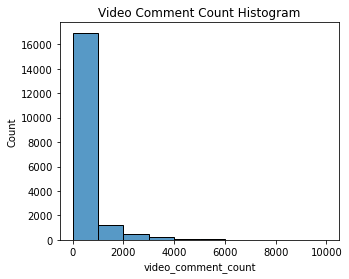

In [72]:
# Create a histogram
plt.figure(figsize = (5,4))
plt.title('Video Comment Count Histogram')
sns.histplot(data['video_comment_count'],  bins = range(0, (10**4+1), 10**3))

**Question:** What do you notice about the distribution of this variable?

The majority of videos are concentrated at the lower end of the comment count range, with most having fewer than 100 comments. The distribution is strongly right-skewed.

#### **video_share_count**

Box plot to examine the spread of values in the `video_share_count` column.

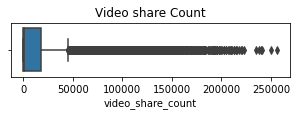

In [76]:
# Create a boxplot to visualize distribution of `video_share_count`
plt.figure(figsize  = (5,1))
plt.title('Video share Count')
sns.boxplot(data['video_share_count'])


Histogram of the values in the `video_share_count` column to further explore the distribution of this variable.

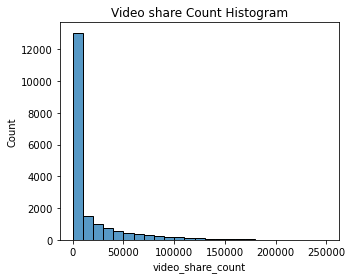

In [88]:
# Create a histogram
plt.figure(figsize  = (5,4))
plt.title('Video share Count Histogram')
sns.histplot(data['video_share_count'], bins=range(0,(250001),10000))


Most videos had fewer than 10,000 shares, with the distribution being highly right-skewed.

#### **video_download_count**

Box plot to examine the spread of values in the `video_download_count` column.

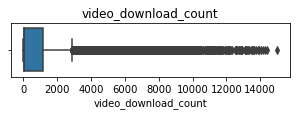

In [91]:
# Create a boxplot to visualize distribution of `video_download_count`
plt.figure(figsize = (5,1))
plt.title('video_download_count')
sns.boxplot(data['video_download_count'])

Histogram of the values in the `video_download_count` column to further explore the distribution of this variable.

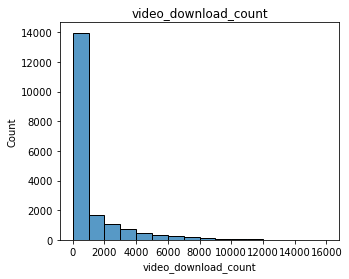

In [93]:
# Create a histogram
plt.figure(figsize = (5,4))
plt.title('video_download_count')
sns.histplot(data['video_download_count'], bins = range(0, 16000+1, 1000))


The distribution is again highly right-skewed, with most videos having fewer than 1,000 downloads.

#### **Claim status by verification status**

A histogram is created with four bars, each representing a combination of claim status and verification status. This visualization helps to compare the distribution of the data across different categories.

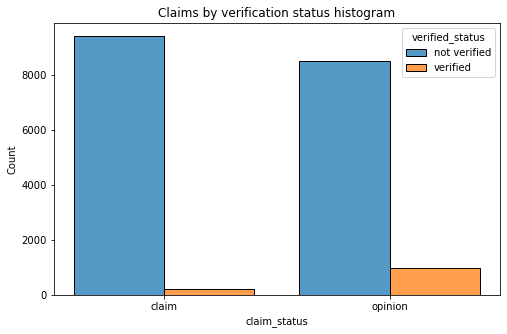

In [102]:
# Create a histogram
plt.figure(figsize = (8,5))
plt.title('Claim Status by verigication status')
sns.histplot(data = data,
            x = 'claim_status',
            hue = 'verified_status',
            multiple = 'dodge',
            shrink = 0.8
            )
plt.title('Claims by verification status histogram');


Verified users are considerably fewer than unverified users. However, when a user is verified, they are more likely to post opinions rather than claims.

#### **Claim status by author ban status**

In the previous stage, a groupby() statement was used to examine the count of each claim status for each author ban status. Now, a histogram is used to visually represent the same information.

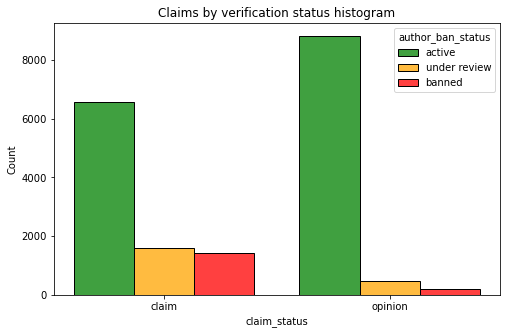

In [109]:
# Create a histogram
# Create a histogram
plt.figure(figsize = (8,5))

sns.histplot(data = data,
            x = 'claim_status',
            hue = 'author_ban_status',
            hue_order=['active', 'under review', 'banned'],
            palette = {'active':'green','under review':'orange', 'banned':'red'},
            multiple = 'dodge',
            shrink = 0.8,
            )
plt.title('Claims by verification status histogram');

There are significantly more active authors than banned authors or authors under review for both claim and opinion videos. However, the proportion of active authors is much higher for opinion videos compared to claim videos. This suggests that authors posting claim videos are more likely to be reviewed or banned.

#### **Median view counts by ban status**

A bar plot is created with three bars representing the different author ban statuses. Each bar's height corresponds to the median number of views for all videos with that specific author ban status. This visualization provides insight into how views vary across the different author ban categories.

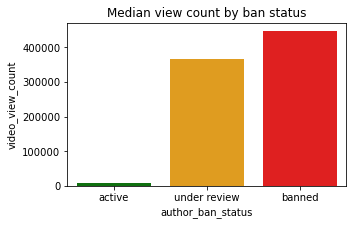

In [112]:
# Create a bar plot
ban_status_counts = data.groupby(['author_ban_status']).median(
    numeric_only=True).reset_index()

fig = plt.figure(figsize=(5,3))
sns.barplot(data=ban_status_counts,
            x='author_ban_status',
            y='video_view_count',
            order=['active', 'under review', 'banned'],
            palette={'active':'green', 'under review':'orange', 'banned':'red'})
plt.title('Median view count by ban status');

The median view counts for non-active authors are notably higher compared to active authors. Since non-active authors are more likely to post claims, and their videos generally receive more views than those of active authors, the `video_view_count` could be a strong predictor of claim status.

In [114]:
# Calculate the median view count for claim status.
data.groupby('claim_status')['video_view_count'].median()

claim_status
claim      501555.0
opinion      4953.0
Name: video_view_count, dtype: float64

#### **Total views by claim status**

A pie chart was created to visualize the proportions of total views for claim videos versus total views for opinion videos. This helps in understanding the distribution of views between these two types of videos.

Text(0.5, 1.0, 'Total views by video claim status')

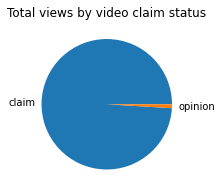

In [118]:
# Create a pie graph
fig=plt.figure(figsize =(3,3))
plt.pie(data.groupby('claim_status')['video_view_count'].sum(), labels = ['claim','opinion'])
plt.title('Total views by video claim status')

Although the dataset contains approximately an equal number of claim and opinion videos, claim videos dominate the overall view count.

### **Determine outliers**

In this step, I will determine the number of outliers for each count variable by calculating the Interquartile Range (IQR) and adjusting the threshold based on the median value. This will help identify any data points that significantly deviate from the expected range.

In [119]:
count_cols = ['video_view_count',
              'video_like_count',
              'video_share_count',
              'video_download_count',
              'video_comment_count',
              ]

for column in count_cols:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    median = data[column].median()
    outlier_threshold = median + 1.5*iqr

    # Count the number of values that exceed the outlier threshold
    outlier_count = (data[column] > outlier_threshold).sum()
    print(f'Number of outliers, {column}:', outlier_count)

Number of outliers, video_view_count: 2343
Number of outliers, video_like_count: 3468
Number of outliers, video_share_count: 3732
Number of outliers, video_download_count: 3733
Number of outliers, video_comment_count: 3882


#### **Scatterplot**

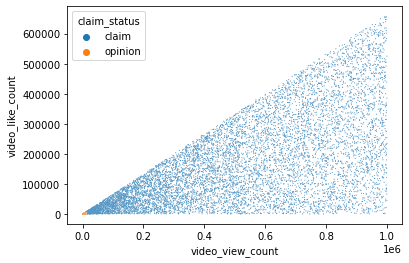

In [124]:
# Create a scatterplot of `video_view_count` versus `video_like_count` according to 'claim_status'
sns.scatterplot(x=data['video_view_count'], 
                y = data['video_like_count'],
                hue = data['claim_status'],
                s= 1)

plt.show()

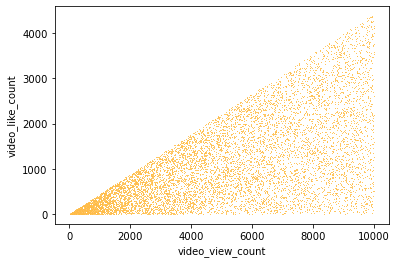

In [132]:
# Create a scatterplot of ``video_view_count` versus `video_like_count` for opinions only
opinion = data[data['claim_status'] == 'opinion']
sns.scatterplot(x=opinion['video_view_count'], 
                y = opinion['video_like_count'],
                color = ['orange'],
                s= 1)

plt.show()



You can do a scatterplot in Tableau Public as well, which can be easier to manipulate and present. If you'd like step by step instructions, you can review the instructions linked in the previous Activity page.

## **PACE: Execute**

### **Conclusion**


Exploratory Data Analysis (EDA) is crucial as it helps a data professional to better understand the dataset, identify potential outliers, handle missing values, and clean the data in preparation for future modeling. Through EDA, the overall structure of the data becomes clear, and decisions can be made on the best way to handle issues such as outliers, duplicates, or missing values. This process is an essential first step before any predictive model can be developed.

Visualizations played a key role in helping to gain insights into the dataset, particularly in understanding the distributions and relationships between variables. For example, the visualizations have indicated areas where further investigation is needed, such as distinguishing characteristics of claim and opinion videos, and highlighted potential factors that could influence future models.

Looking ahead, it is important to create additional visuals that could shed light on other key aspects of the data. The visualizations already created, combined with further analysis, will support informed decisions during the model-building phase.

By completing this professional data visualization process, valuable insights have been derived, which will inform the next steps in the development of a robust model.
